# Assignment 3: Practical Data Science Group Project
---

**Dataset:** Online Shoppers Purchasing Intention Dataset

**Problem Type:** Problem Type 1 - Data Modeling (Classification and Clustering)

---

## Team Information

**Course:** COSC2789: Practical Data Science

**Assignment:** Assignment 3 - Group Project

**Group:** UG2

---

### Author Information

| Name | Student ID | Email |
|------|------------|-------|
| Do Duy Hung | s3991053 | s3991053@rmit.edu.vn |
| Ho Dinh Gia Bao | s4028938 | s4028938@rmit.edu.vn |

**Affiliation:** RMIT University, SSET

**Date of Report:** January 15, 2026

## Task 0: Choosing Your Project Topic

### Problem Type Selection

We have selected **Problem Type 1: Data Modeling (Classification and Clustering)** for this assignment.

### Dataset

**Dataset Name:** Online Shoppers Purchasing Intention Dataset

**Source:** UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

**Citation:** Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

**Dataset Characteristics:**
- 12,330 sessions from an e-commerce website
- 18 features (10 numerical, 8 categorical)
- 1-year period data collection
- Each session represents a different user

### Research Questions

We are addressing **TWO** data science tasks:

#### Task 1: Classification Problem
**Objective:** Predict whether a visitor will make a purchase (Revenue = 1) based on their session behavior and characteristics.

**Business Goal:** Build predictive models to identify high-intent purchasers in real-time, enabling:
- Targeted promotional offers to likely buyers
- Resource optimization for customer service
- Improved conversion rate through personalized experiences

**Target Variable:** Revenue (Binary: 0 = No Purchase, 1 = Purchase)

**Expected Outcome:** A classification model that accurately predicts purchase intention, helping the business focus marketing efforts on high-potential customers.

#### Task 2: Clustering Problem
**Objective:** Segment website visitors into distinct behavioral groups based on browsing patterns, engagement metrics, and session characteristics.

**Business Goal:** Understand different user personas to develop:
- Targeted marketing strategies for each segment
- Customized user experiences based on cluster characteristics
- Insights into customer behavior patterns

**Clustering Features:** Page visit patterns, browsing duration, engagement metrics (bounce/exit rates), temporal patterns, and visitor characteristics.

**Expected Outcome:** Identification of 3-5 distinct user segments with clear behavioral profiles, enabling data-driven marketing personalization.

### Deliverables

1. **Classification Models:** Build and compare at least 3 classification algorithms (Logistic Regression, Random Forest, XGBoost) to predict purchase behavior
2. **Clustering Models:** Apply and compare at least 3 clustering algorithms (K-Means, Hierarchical Clustering, DBSCAN) to identify user segments
3. **Model Evaluation:** Comprehensive performance metrics and comparison for both tasks
4. **Business Insights:** Actionable recommendations based on model findings

## Task 1: Retrieving and Preparing the Data


### 1.1 Project Goal

We are choosing the Online Shoppers Purchasing Intention dataset to solve a business problem in e-commerce. The goal is to predict whether a visitor will make a purchase during their session (classification task) and to identify different groups of user behaviors through clustering analysis. 

This dataset contains 12,330 sessions from an online shopping website over a 1-year period. Each session includes information about page visits, user behavior metrics from Google Analytics, and visitor characteristics. The target variable is Revenue, which indicates whether the session ended with a purchase.

Our analytical goal for this phase is to thoroughly understand the dataset, clean it properly, and explore the patterns in the data. This will provide a solid foundation for building accurate classification and clustering models later.


### 1.2 Load Data


In [2]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
# load dataset
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (12330, 18)

Number of rows: 12330
Number of columns: 18


In [4]:
# display first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 1.3 Data Inspection

Before we proceed with analysis, we need to understand the data quality and structure. We will check for missing values, data types, duplicates, and any potential issues that might affect our modeling.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
# check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percentage
})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


In [7]:
# check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 125
Percentage of duplicates: 1.01%


In [8]:
# summary statistics for numerical columns
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
# check categorical columns and their unique values
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Categorical Columns and Their Unique Values:\n")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    print(f"  Values: {df[col].unique()}\n")

Categorical Columns and Their Unique Values:

Month: 10 unique values
  Values: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unique values
  Values: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unique values
  Values: [False  True]

Revenue: 2 unique values
  Values: [False  True]



**Key Findings from Data Inspection:** (later use this for report)

From the inspection above, we can observe:

1. **No Missing Values**: All 18 columns have complete data with 12,330 non-null entries. This is excellent for our analysis as we do not need to handle missing data.

2. **Duplicate Rows**: There are 125 duplicate rows (1.01%). Since the dataset was designed to have each session from a different user, these duplicates may represent genuine repeated patterns or data collection issues. We will need to decide whether to keep or remove them.

3. **Data Types**: The dataset has a good mix of features:
   - 7 numerical integer columns (page counts and system identifiers)
   - 7 numerical float columns (durations and Google Analytics metrics)
   - 2 categorical object columns (Month, VisitorType)
   - 2 boolean columns (Weekend, Revenue)

4. **Target Variable**: Revenue is our target for classification, with False (no purchase) and True (purchase). This is a binary classification problem.

5. **Numerical Features**: The summary statistics show reasonable ranges. For example, ProductRelated pages range from 0 to 705, and durations vary widely, suggesting diverse user behaviors.

6. **Categorical Features**: Month has 10 values, VisitorType has 3 categories, which will need encoding for modeling.


### 1.4 Preprocessing (Checking for Issues)

Now we will identify the column types and create a preprocessing plan for encoding and transformation.


In [10]:
# identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)
print(f"\nTotal: {len(numerical_cols)} columns")

print("\n" + "="*50 + "\n")

print("Categorical Columns:")
print(categorical_cols)
print(f"\nTotal: {len(categorical_cols)} columns")

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Total: 14 columns


Categorical Columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Total: 4 columns


In [11]:
# target variable distribution (print)
print("Target Variable (Revenue) Distribution:")
print(df['Revenue'].value_counts())
print("\nPercentage Distribution:")
print(df['Revenue'].value_counts(normalize=True) * 100)


Target Variable (Revenue) Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage Distribution:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


**Column Classification:** (later use this for report)

We have identified:
- **14 numerical columns**: These include page visit counts, durations, and Google Analytics metrics
- **4 categorical columns**: Month, VisitorType, Weekend, and Revenue (our target)

**Target Variable Analysis:**

The Revenue column shows a class imbalance:
- False (No purchase): 10,422 sessions (84.53%)
- True (Purchase): 1,908 sessions (15.47%)

This imbalance is typical in e-commerce datasets where most visitors browse without purchasing. We will need to consider this imbalance when building our classification models later.

In [12]:
# check for potential outliers using IQR method for key numerical columns
def detect_outliers_iqr(data, columns):
    outlier_summary = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(data)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Percentage': round(outlier_percentage, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })
    return pd.DataFrame(outlier_summary)

# check outliers for duration and metric columns
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
outlier_df = detect_outliers_iqr(df, outlier_cols)
print("Outlier Detection Summary (IQR Method):")
print(outlier_df)

Outlier Detection Summary (IQR Method):
                    Column  Outlier_Count  Percentage  Lower_Bound  \
0  Administrative_Duration           1172        9.51      -139.88   
1   Informational_Duration           2405       19.51         0.00   
2  ProductRelated_Duration            961        7.79     -1735.89   
3              BounceRates           1551       12.58        -0.03   
4                ExitRates           1099        8.91        -0.04   
5               PageValues           2730       22.14         0.00   

   Upper_Bound  
0       233.14  
1         0.00  
2      3384.19  
3         0.04  
4         0.10  
5         0.00  


In [13]:
# check for any negative or impossible values in duration columns
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
print("Checking for negative values in duration columns:\n")
for col in duration_cols:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

# check if BounceRates and ExitRates are within valid range [0, 1]
print("\n" + "="*50)
print("\nChecking valid ranges for rate columns:\n")
for col in ['BounceRates', 'ExitRates']:
    invalid_count = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {invalid_count} values outside [0, 1] range")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

Checking for negative values in duration columns:

Administrative_Duration: 0 negative values
Informational_Duration: 0 negative values
ProductRelated_Duration: 0 negative values


Checking valid ranges for rate columns:

BounceRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2
ExitRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2


**Data Quality Findings:** (later use this for report)

From the outlier and data quality checks:

1. **No Invalid Values**: All duration columns have non-negative values, and BounceRates and ExitRates are within the valid range [0, 0.2], which is appropriate for these Google Analytics metrics.

2. **Outliers Present**: Several columns contain outliers based on the IQR method:
   - PageValues: 22.14% outliers - high page values indicate valuable sessions
   - Informational_Duration: 19.51% outliers - some users spend much longer on informational pages
   - BounceRates: 12.58% outliers - higher bounce rates may indicate poor engagement
   - Administrative_Duration: 9.51% outliers
   - ExitRates: 8.91% outliers
   - ProductRelated_Duration: 7.79% outliers

3. **Outlier Decision**: These outliers appear to represent genuine user behavior patterns (e.g., some users browse much longer or have higher engagement). We will keep these outliers as they may contain important information for predicting purchase behavior.


**Preprocessing Plan:**

Based on our inspection, here is our preprocessing strategy:

1. **Duplicate Handling**: We will remove the 125 duplicate rows (1.01%) since the dataset was designed to have unique user sessions.

2. **Categorical Encoding Strategy** (to be applied later during modeling):
   - **Month**: Use One-Hot Encoding (10 categories: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec)
   - **VisitorType**: Use One-Hot Encoding (3 categories: Returning_Visitor, New_Visitor, Other)
   - **Weekend**: Already boolean, convert to binary (0/1)
   - **Revenue**: Target variable, convert to binary (0/1)

3. **Numerical Features**: Keep as-is for now. No scaling will be applied at this stage - scaling will be done during the modeling phase to prevent data leakage.

4. **Outliers**: Keep all outliers as they represent valid user behavior patterns.

5. **Feature Engineering**: Will be addressed in Task 2, including correlation analysis and feature selection.


In [14]:
# remove duplicate rows
df_clean = df.drop_duplicates()
print(f"Original dataset size: {df.shape[0]} rows")
print(f"After removing duplicates: {df_clean.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} duplicate rows")

Original dataset size: 12330 rows
After removing duplicates: 12205 rows
Removed: 125 duplicate rows


**Task 1 Summary:** (later use this for report)

We have successfully completed the data retrieval and preparation phase:
- Loaded 12,330 sessions with 18 features
- Confirmed no missing values
- Identified and removed 125 duplicate rows
- Detected outliers but decided to keep them as they represent genuine patterns
- Validated data quality (no negative durations, rates within valid ranges)
- Created a preprocessing plan for encoding categorical variables

The cleaned dataset is now ready for exploratory analysis and feature engineering.


## Task 2: Feature Engineering

Before we proceed with feature engineering, we need to understand the distribution and relationships within our data. This exploratory analysis will help us make informed decisions about feature extraction, transformation, and selection. (we will do Exploratory Data Analysis first)


### 2.1 Univariate Analysis

We will examine individual features to understand their distributions and characteristics. This will help us identify patterns and potential issues before modeling.


**2.1.1 Target Variable: Revenue**

We start by examining our target variable to understand the class distribution.


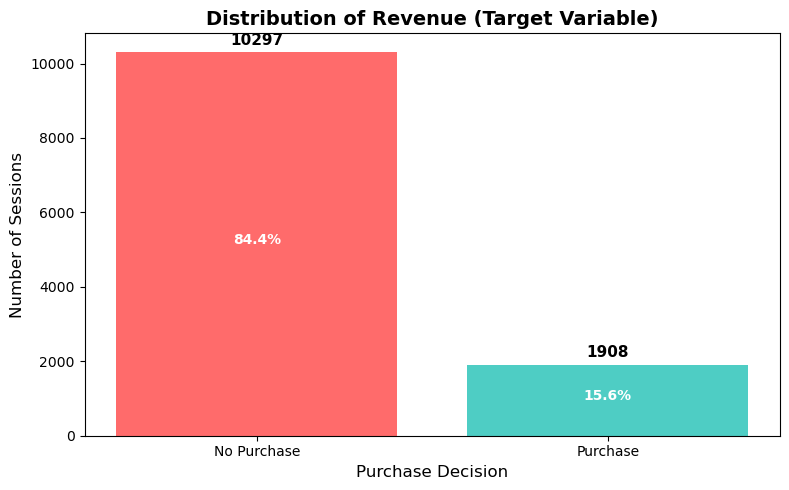

In [15]:
# visualize target variable distribution
plt.figure(figsize=(8, 5))
revenue_counts = df_clean['Revenue'].value_counts()
plt.bar(['No Purchase', 'Purchase'], revenue_counts.values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribution of Revenue (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Purchase Decision', fontsize=12)

# add value labels on bars
for i, v in enumerate(revenue_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


The target variable shows significant class imbalance with 84.4% non-purchase sessions and 15.6% purchase sessions. This imbalance is typical in e-commerce where most visitors browse without buying. This will be important to address during modeling, potentially using techniques like SMOTE or class weighting.


**2.1.2 Product-Related Features**

These features track user interaction with product pages, which are likely strong predictors of purchase behavior.


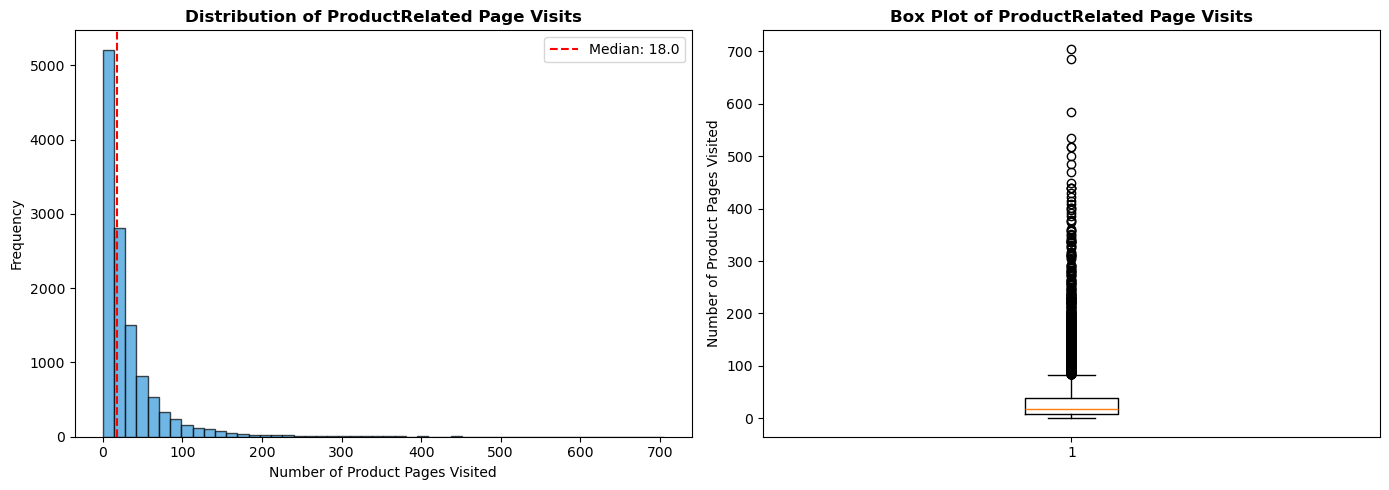

Mean: 32.05
Median: 18.00
Std: 44.59


In [16]:
# distribution of ProductRelated pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ProductRelated'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Product Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated'].mean():.2f}")
print(f"Median: {df_clean['ProductRelated'].median():.2f}")
print(f"Std: {df_clean['ProductRelated'].std():.2f}")


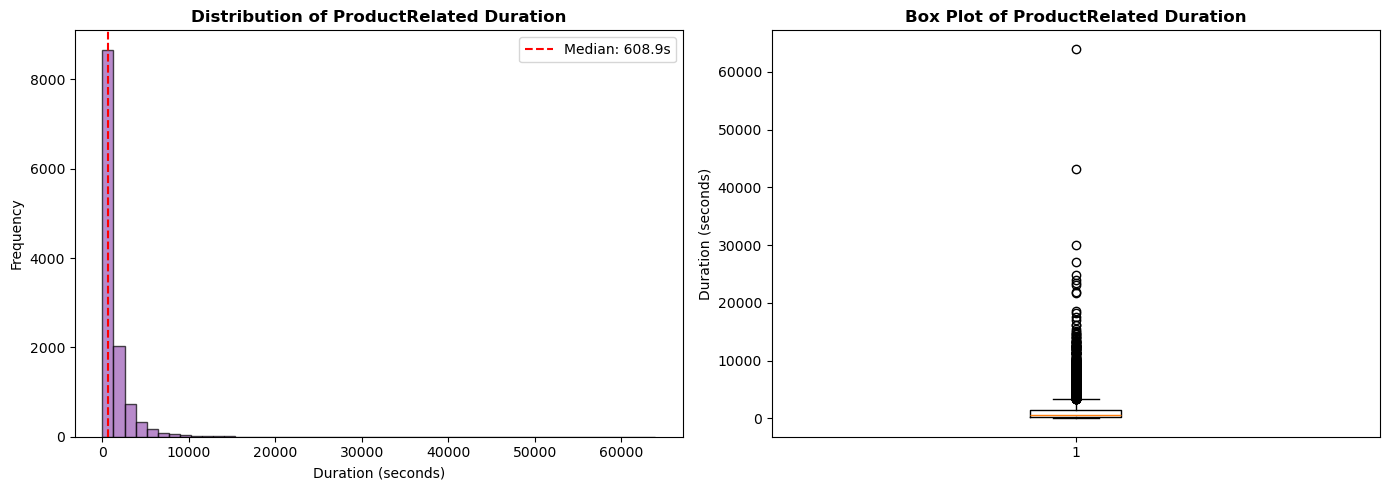

Mean: 1206.98 seconds
Median: 608.94 seconds


In [17]:
# distribution of ProductRelated_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram with log scale for better visualization
axes[0].hist(df_clean['ProductRelated_Duration'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated_Duration'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['ProductRelated_Duration'].median():.2f} seconds")


The ProductRelated features show right-skewed distributions. Most users visit around 18 product pages (median) with a mean of 31.7 pages, indicating some users browse extensively. The duration also shows high variability with a median of 609 seconds (about 10 minutes). The presence of many outliers in the boxplot suggests diverse browsing behaviors, which may be useful for clustering analysis.


**2.1.3 PageValues (Transaction Value Indicator)**

PageValues represents the average value of pages visited before a transaction. This is a critical feature as it directly relates to purchase intent.


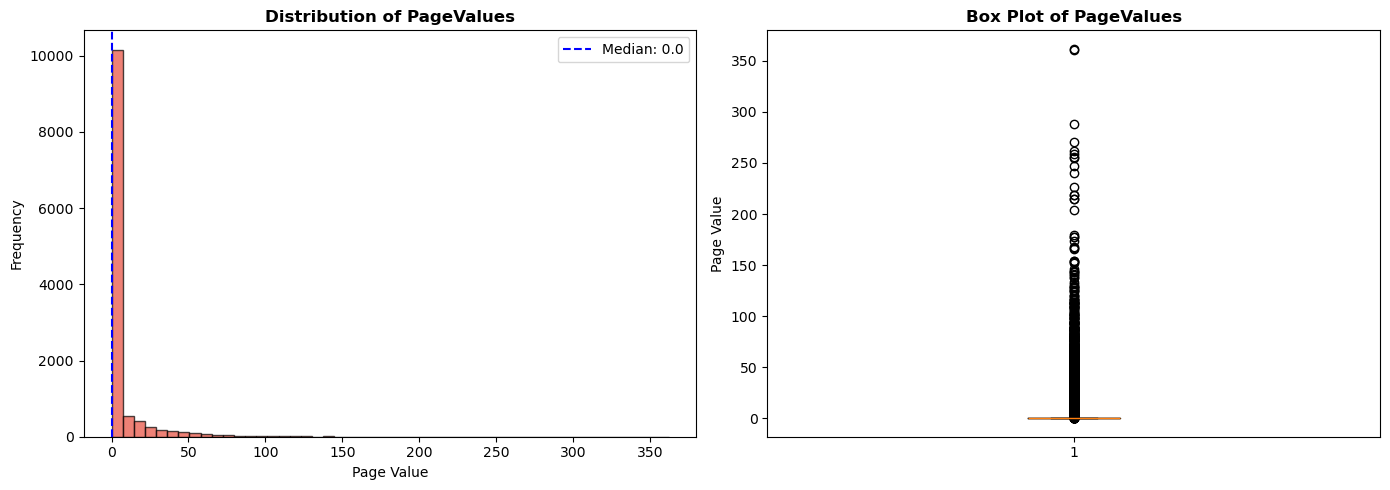

Mean: 5.95
Median: 0.00
Non-zero PageValues: 2730 (22.4%)


In [18]:
# distribution of PageValues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['PageValues'], bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of PageValues', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Page Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['PageValues'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["PageValues"].median():.1f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['PageValues'], vert=True)
axes[1].set_title('Box Plot of PageValues', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Page Value', fontsize=10)

plt.tight_layout()
plt.show()

# statistics
print(f"Mean: {df_clean['PageValues'].mean():.2f}")
print(f"Median: {df_clean['PageValues'].median():.2f}")
print(f"Non-zero PageValues: {(df_clean['PageValues'] > 0).sum()} ({(df_clean['PageValues'] > 0).sum() / len(df_clean) * 100:.1f}%)")


PageValues is highly skewed with median of 0, meaning 77.6% of sessions have zero page value (no purchase intent tracked). Only 22.4% of sessions show non-zero values, which aligns with our purchase rate. This feature will be a strong predictor for classification.

**2.1.4 BounceRates (Engagement Metric)**

BounceRate indicates the percentage of visitors who leave immediately. Lower bounce rates typically suggest better engagement.


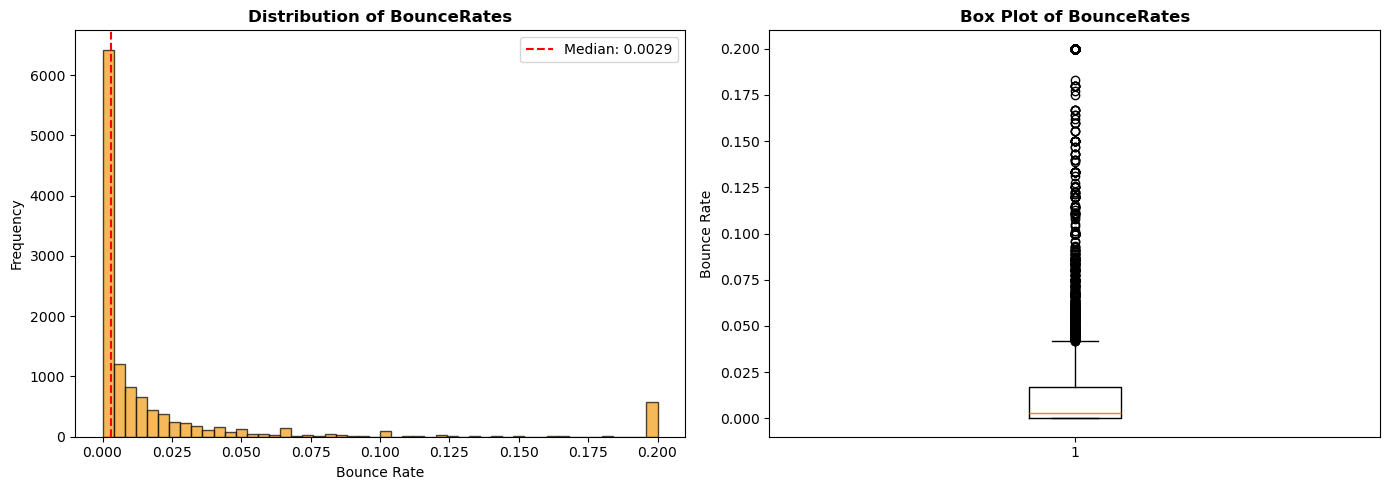

Mean: 0.0204
Median: 0.0029


In [19]:
# distribution of BounceRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['BounceRates'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of BounceRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bounce Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['BounceRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["BounceRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['BounceRates'], vert=True)
axes[1].set_title('Box Plot of BounceRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bounce Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['BounceRates'].mean():.4f}")
print(f"Median: {df_clean['BounceRates'].median():.4f}")


BounceRates show that most sessions have very low bounce rates (median 0.0029), indicating users generally engage with multiple pages. The presence of outliers at higher bounce rates suggests some sessions with poor engagement.

**2.1.5 ExitRates (Session Ending Metric)**

ExitRate measures the percentage of pageviews that were the last in the session. This helps identify pages where users leave the site.


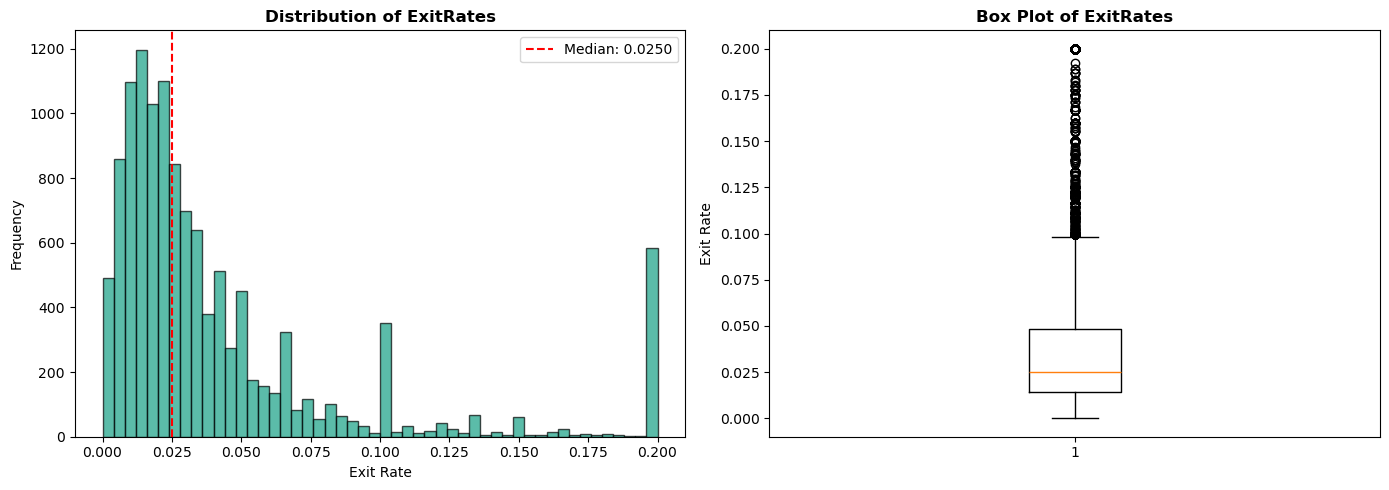

Mean: 0.0415
Median: 0.0250


In [20]:
# distribution of ExitRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ExitRates'], bins=50, color='#16a085', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ExitRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Exit Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ExitRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ExitRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ExitRates'], vert=True)
axes[1].set_title('Box Plot of ExitRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ExitRates'].mean():.4f}")
print(f"Median: {df_clean['ExitRates'].median():.4f}")


ExitRates have a median of 0.025 with more spread than BounceRates. The distribution shows that exit behavior varies significantly across sessions, which may help differentiate between purchasers and non-purchasers.

**2.1.6 Month (Seasonal Patterns)**

Understanding the temporal distribution of sessions can reveal seasonal shopping trends.


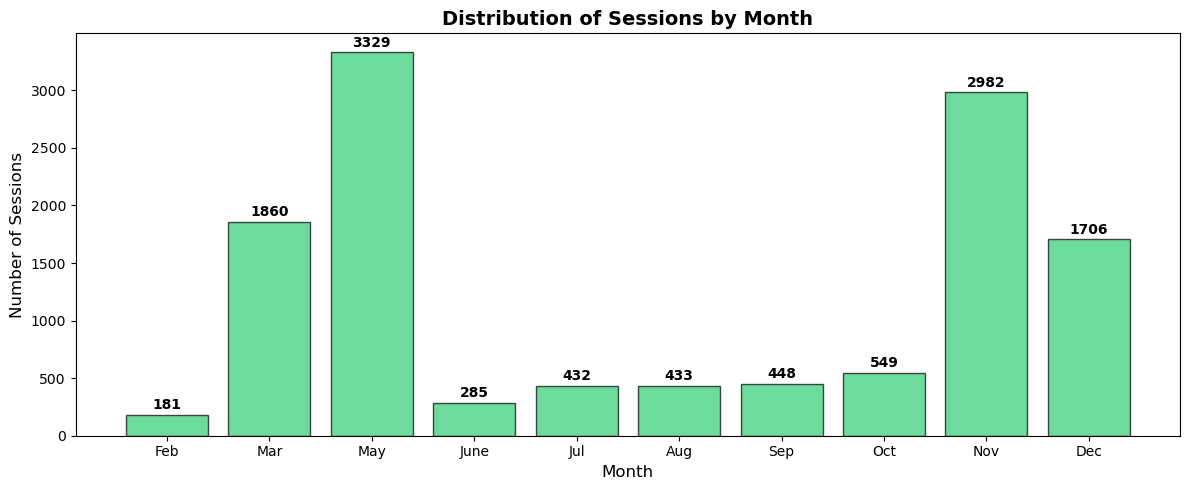


Session counts by month:
Month
Feb      181
Mar     1860
May     3329
June     285
Jul      432
Aug      433
Sep      448
Oct      549
Nov     2982
Dec     1706
Name: count, dtype: int64


In [21]:
# distribution of sessions by month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_counts = df_clean['Month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(month_counts.index, month_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(month_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by month:")
print(month_counts)


Sessions are heavily concentrated in May (3,329 sessions) and November (2,982 sessions), likely corresponding to major shopping events. March and December also show high activity. This seasonal pattern suggests shopping behavior varies by month and could be useful for both classification and clustering.


**2.1.7 VisitorType (User Segmentation)**

VisitorType categorizes users as returning visitors, new visitors, or other. This may influence purchase behavior.


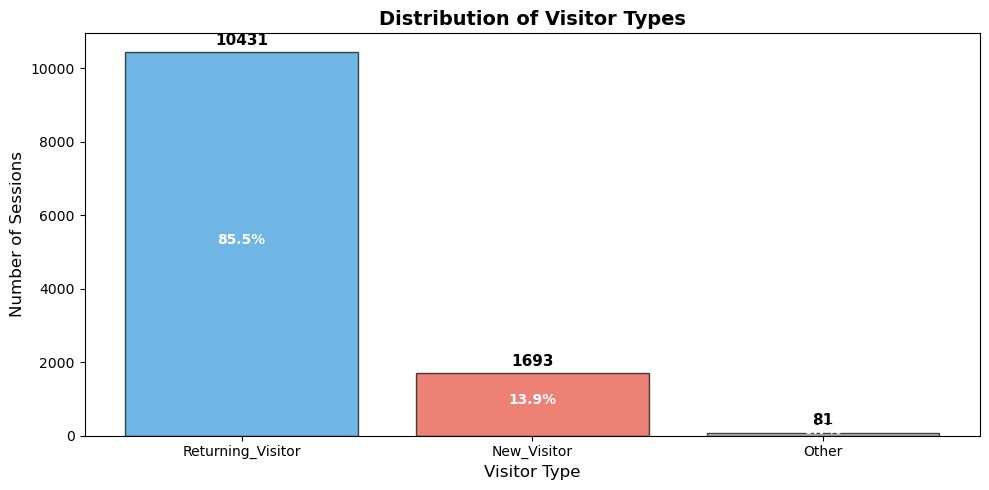

Visitor type distribution:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Percentages:
VisitorType
Returning_Visitor    85.464973
New_Visitor          13.871364
Other                 0.663662
Name: count, dtype: float64


In [22]:
# distribution of VisitorType
visitor_counts = df_clean['VisitorType'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(visitor_counts.index, visitor_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Visitor Types', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(visitor_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visitor type distribution:")
print(visitor_counts)
print(f"\nPercentages:")
print(visitor_counts / len(df_clean) * 100)


The majority of sessions are from returning visitors (85.5%), with only 13.9% from new visitors. This suggests the website has a strong repeat visitor base. The "Other" category is minimal (0.7%). This imbalance may influence purchase patterns and will be important for clustering analysis.

**2.1.8 Weekend (Temporal Pattern)**

Understanding whether sessions occur on weekends versus weekdays may reveal different shopping behaviors.


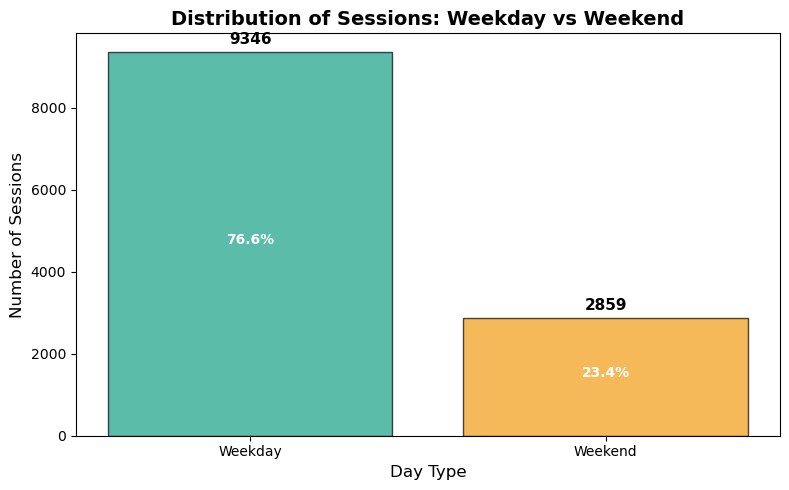

Weekend distribution:
Weekend
False    9346
True     2859
Name: count, dtype: int64

Percentages:
Weekend
False    76.575174
True     23.424826
Name: count, dtype: float64


In [23]:
# distribution of Weekend sessions
weekend_counts = df_clean['Weekend'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Weekday', 'Weekend'], weekend_counts.values, color=['#16a085', '#f39c12'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(weekend_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Weekend distribution:")
print(weekend_counts)
print(f"\nPercentages:")
print(weekend_counts / len(df_clean) * 100)


Most sessions occur on weekdays (76.6%) compared to weekends (23.4%). This is expected for online shopping, though weekend sessions might show different purchasing behaviors worth investigating in bivariate analysis.


**2.1.9 Administrative Pages**

Administrative pages typically include account management, login, and registration pages. Understanding how users interact with these pages can provide insights into user engagement.

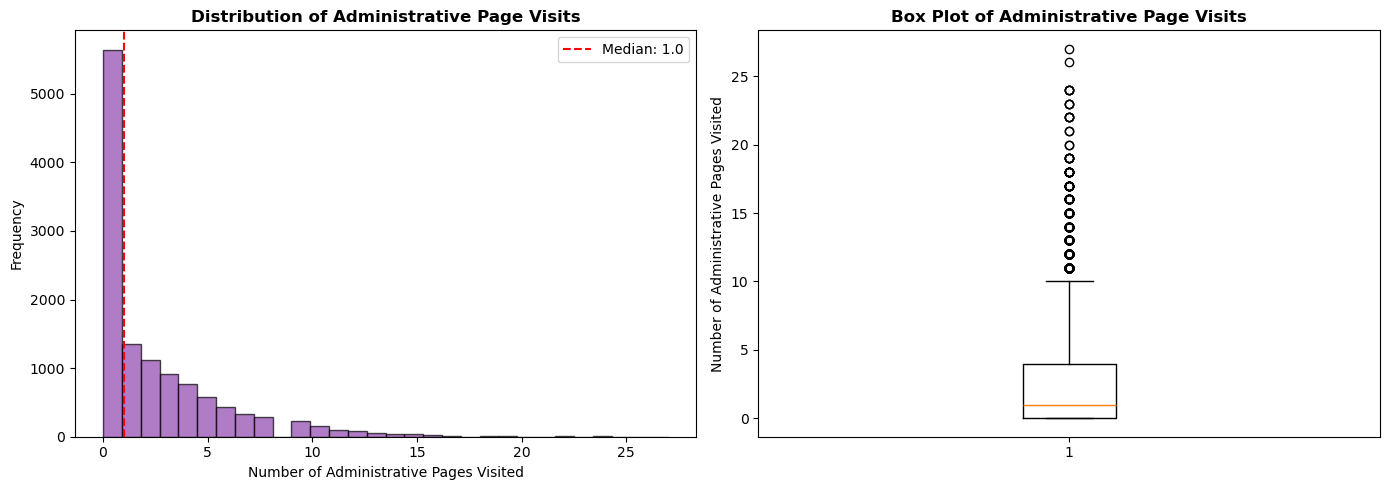

Mean: 2.34
Median: 1.00
Std: 3.33


In [24]:
# distribution of Administrative pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative'], bins=30, color='#8e44ad', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Administrative Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative'], vert=True)
axes[1].set_title('Box Plot of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Administrative Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative'].mean():.2f}")
print(f"Median: {df_clean['Administrative'].median():.2f}")
print(f"Std: {df_clean['Administrative'].std():.2f}")

Administrative pages show a heavily right-skewed distribution with a median of 1 page. Most users visit very few administrative pages, which is expected as these are typically for account management. The outliers suggest some users engage more with account-related features, possibly during registration or checkout.

**2.1.10 Administrative_Duration**

This feature represents the total time spent on administrative pages during a session.

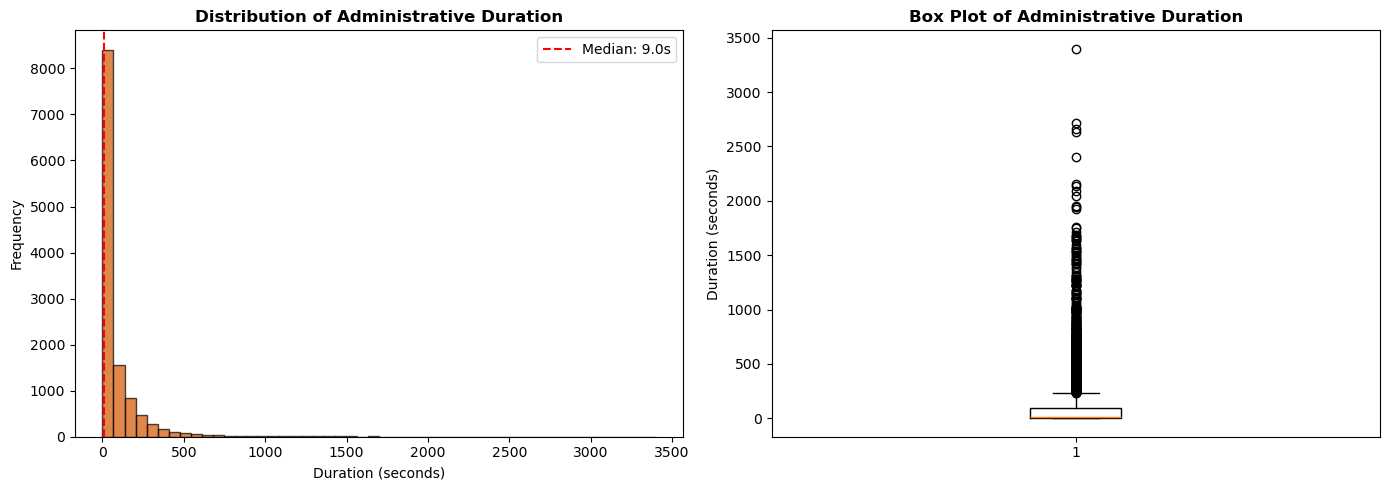

Mean: 81.65 seconds
Median: 9.00 seconds


In [25]:
# distribution of Administrative_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative_Duration'], bins=50, color='#d35400', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative_Duration'], vert=True)
axes[1].set_title('Box Plot of Administrative Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Administrative_Duration'].median():.2f} seconds")

Administrative duration is also right-skewed with a low median of 9 seconds. Most sessions spend minimal time on administrative pages. The presence of outliers indicates some users spend significantly longer, possibly completing account setup or dealing with issues.

**2.1.11 Informational Pages**

Informational pages include content like FAQs, shipping information, and about pages. These help users make informed decisions.

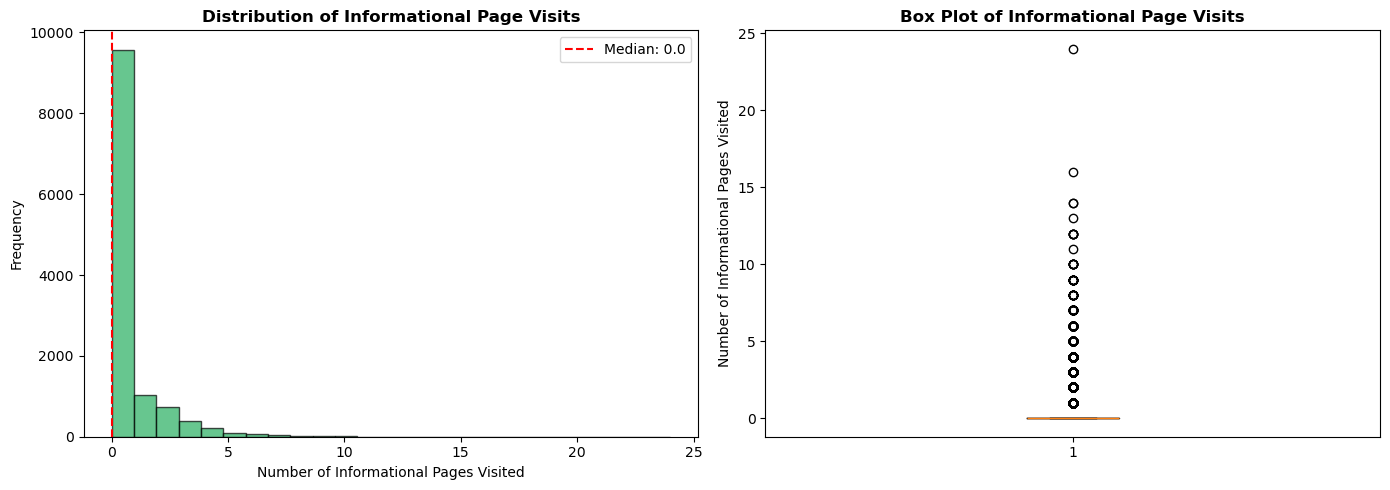

Mean: 0.51
Median: 0.00
Std: 1.28


In [26]:
# distribution of Informational pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational'], bins=25, color='#27ae60', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Informational Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Informational"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational'], vert=True)
axes[1].set_title('Box Plot of Informational Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Informational Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational'].mean():.2f}")
print(f"Median: {df_clean['Informational'].median():.2f}")
print(f"Std: {df_clean['Informational'].std():.2f}")

Informational pages show an even more extreme distribution with a median of 0, meaning most users skip informational pages entirely. Only a small portion of users seek out FAQs or shipping information, suggesting they may already be familiar with the site or prefer to browse products directly.

**2.1.12 Informational_Duration**

This measures the time spent reading informational content during a session.

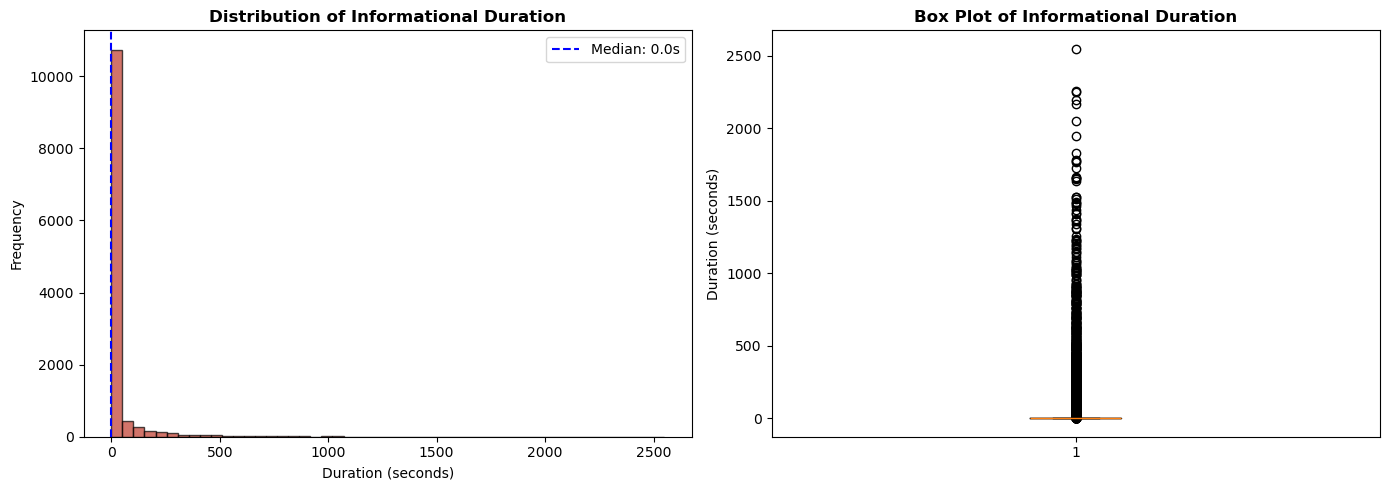

Mean: 34.83 seconds
Median: 0.00 seconds


In [27]:
# distribution of Informational_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational_Duration'], bins=50, color='#c0392b', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational_Duration'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["Informational_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational_Duration'], vert=True)
axes[1].set_title('Box Plot of Informational Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Informational_Duration'].median():.2f} seconds")

Informational duration has a median of 0 seconds, confirming that most sessions do not interact with informational content. When users do access these pages, there is high variability in time spent, as shown by the outliers.

**2.1.13 SpecialDay**

SpecialDay indicates the closeness of the session to special occasions like Valentine's Day or Mother's Day, which may influence shopping behavior.

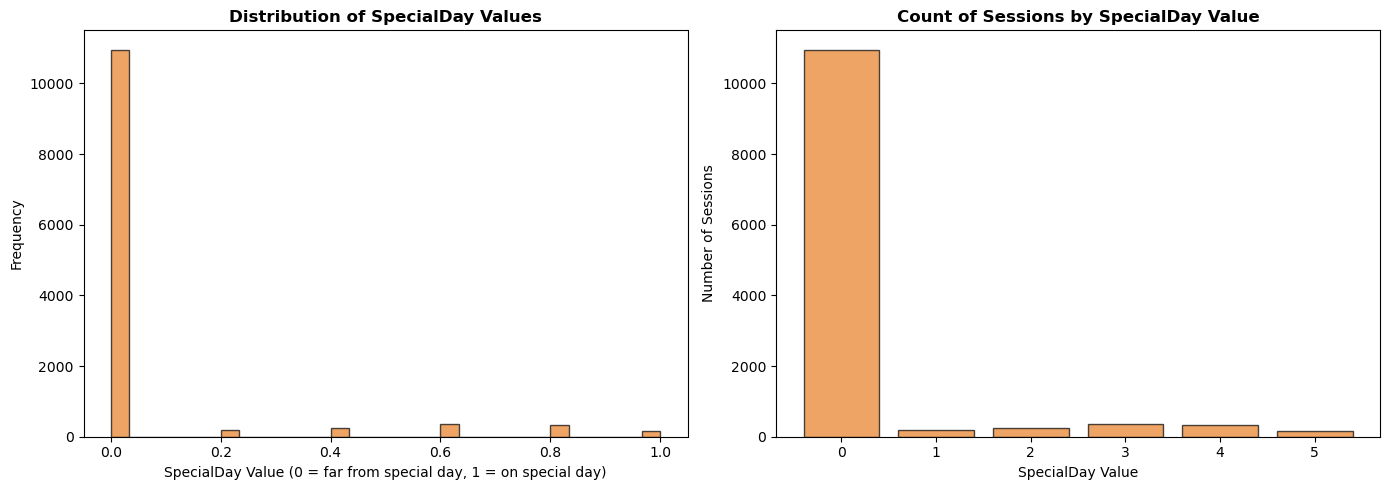

Mean: 0.0619
Median: 0.0000

Sessions with SpecialDay = 0: 10956 (89.8%)
Sessions with SpecialDay > 0: 1249 (10.2%)


In [28]:
# distribution of SpecialDay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['SpecialDay'], bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of SpecialDay Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SpecialDay Value (0 = far from special day, 1 = on special day)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)

# value counts
special_day_counts = df_clean['SpecialDay'].value_counts().sort_index()
axes[1].bar(range(len(special_day_counts)), special_day_counts.values, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_title('Count of Sessions by SpecialDay Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('SpecialDay Value', fontsize=10)
axes[1].set_ylabel('Number of Sessions', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['SpecialDay'].mean():.4f}")
print(f"Median: {df_clean['SpecialDay'].median():.4f}")
print(f"\nSessions with SpecialDay = 0: {(df_clean['SpecialDay'] == 0).sum()} ({(df_clean['SpecialDay'] == 0).sum() / len(df_clean) * 100:.1f}%)")
print(f"Sessions with SpecialDay > 0: {(df_clean['SpecialDay'] > 0).sum()} ({(df_clean['SpecialDay'] > 0).sum() / len(df_clean) * 100:.1f}%)")

SpecialDay shows that the vast majority of sessions occur far from special occasions (value = 0). Only a small number of sessions are close to special days like Valentine's Day or Mother's Day. This suggests most data was collected during regular shopping periods, though the few sessions near special days may show different purchasing patterns worth investigating in bivariate analysis.

### 2.2 Bivariate Analysis

Now we examine relationships between features and our target variable (Revenue). This analysis will help us identify which features are most predictive of purchase behavior and guide our feature selection for modeling.

**2.2.1 Revenue vs PageValues**

From our univariate analysis, we found that PageValues has a median of 0 with only 22.4% non-zero values, which closely matches our purchase rate of 15.6%. We hypothesize that PageValues will be a strong predictor of purchase behavior.

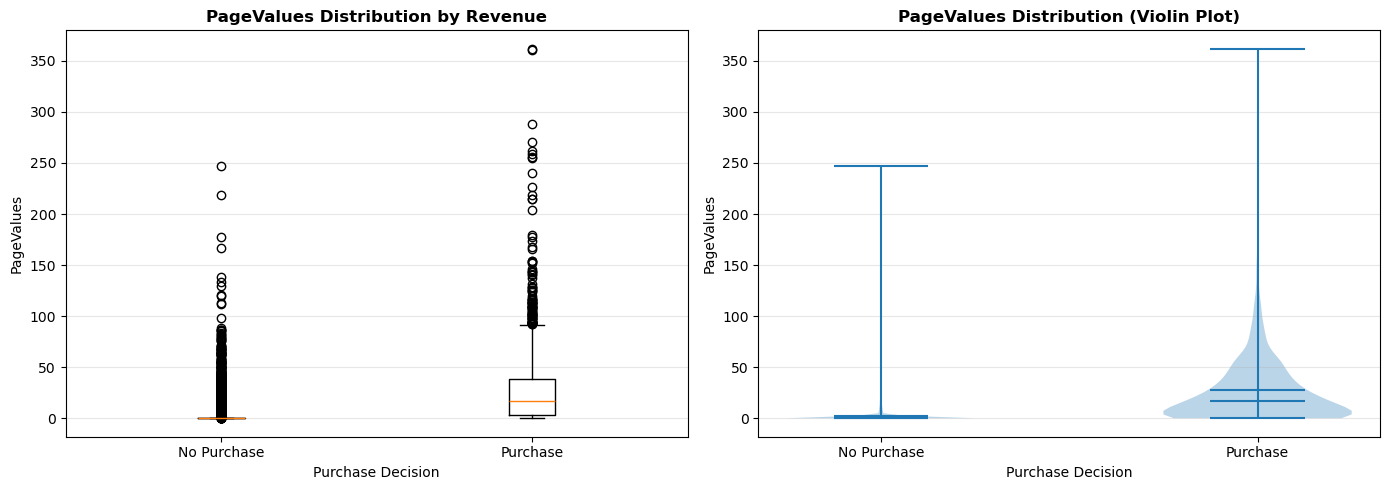

PageValues Statistics by Revenue:

No Purchase Group:
  Mean: 2.00
  Median: 0.00
  Non-zero count: 1192 (11.6%)

Purchase Group:
  Mean: 27.26
  Median: 16.76
  Non-zero count: 1538 (80.6%)


In [29]:
# compare PageValues between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot comparison
purchase_data = df_clean[df_clean['Revenue'] == True]['PageValues']
no_purchase_data = df_clean[df_clean['Revenue'] == False]['PageValues']

axes[0].boxplot([no_purchase_data, purchase_data], labels=['No Purchase', 'Purchase'])
axes[0].set_title('PageValues Distribution by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PageValues', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# violin plot for better distribution view
purchase_df = df_clean.copy()
purchase_df['Revenue_Label'] = purchase_df['Revenue'].map({False: 'No Purchase', True: 'Purchase'})
axes[1].violinplot([no_purchase_data, purchase_data], positions=[0, 1], showmeans=True, showmedians=True)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Purchase', 'Purchase'])
axes[1].set_title('PageValues Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PageValues', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical summary
print("PageValues Statistics by Revenue:\n")
print("No Purchase Group:")
print(f"  Mean: {no_purchase_data.mean():.2f}")
print(f"  Median: {no_purchase_data.median():.2f}")
print(f"  Non-zero count: {(no_purchase_data > 0).sum()} ({(no_purchase_data > 0).sum() / len(no_purchase_data) * 100:.1f}%)")

print("\nPurchase Group:")
print(f"  Mean: {purchase_data.mean():.2f}")
print(f"  Median: {purchase_data.median():.2f}")
print(f"  Non-zero count: {(purchase_data > 0).sum()} ({(purchase_data > 0).sum() / len(purchase_data) * 100:.1f}%)")

**KEY FINDING:** PageValues shows a dramatic difference between purchase and no-purchase groups. The purchase group has a mean PageValues of 27.26 (13.6x higher than no-purchase at 2.00) and a median of 16.76 (compared to 0 for no-purchase). Most importantly, 80.6% of purchases have non-zero PageValues, while only 11.6% of non-purchases do. This confirms PageValues is likely our strongest predictor - it directly measures the value of pages visited before transaction, making it an excellent indicator of purchase intent. This feature will be critical for our classification model.

**2.2.2 Revenue vs ProductRelated Features**

Product-related pages are where users view items for purchase. We expect users who make purchases to visit more product pages and spend more time browsing products.

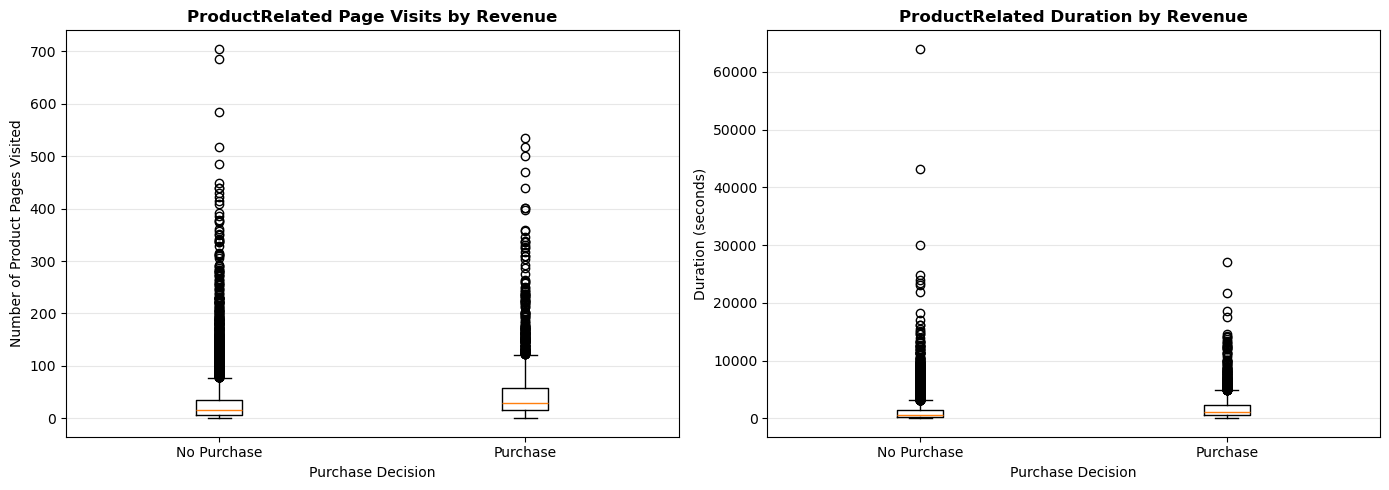

ProductRelated Page Visits by Revenue:

No Purchase - Mean: 29.05, Median: 16.00
Purchase - Mean: 48.21, Median: 29.00
Difference: 19.16 pages (66.0% increase)


ProductRelated Duration by Revenue:

No Purchase - Mean: 1082.98s, Median: 526.00s
Purchase - Mean: 1876.21s, Median: 1109.91s
Difference: 793.23 seconds (73.2% increase)


In [30]:
# compare ProductRelated features between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ProductRelated page visits
pr_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated']
pr_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated']

axes[0].boxplot([pr_no_purchase, pr_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('ProductRelated Page Visits by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ProductRelated Duration
prd_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated_Duration']
prd_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated_Duration']

axes[1].boxplot([prd_no_purchase, prd_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ProductRelated Duration by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("ProductRelated Page Visits by Revenue:\n")
print(f"No Purchase - Mean: {pr_no_purchase.mean():.2f}, Median: {pr_no_purchase.median():.2f}")
print(f"Purchase - Mean: {pr_purchase.mean():.2f}, Median: {pr_purchase.median():.2f}")
print(f"Difference: {pr_purchase.mean() - pr_no_purchase.mean():.2f} pages ({((pr_purchase.mean() / pr_no_purchase.mean() - 1) * 100):.1f}% increase)")

print("\n" + "="*60 + "\n")

print("ProductRelated Duration by Revenue:\n")
print(f"No Purchase - Mean: {prd_no_purchase.mean():.2f}s, Median: {prd_no_purchase.median():.2f}s")
print(f"Purchase - Mean: {prd_purchase.mean():.2f}s, Median: {prd_purchase.median():.2f}s")
print(f"Difference: {prd_purchase.mean() - prd_no_purchase.mean():.2f} seconds ({((prd_purchase.mean() / prd_no_purchase.mean() - 1) * 100):.1f}% increase)")

**KEY FINDING:** Purchasers show significantly higher engagement with product pages. They visit 66% more product pages (48.2 vs 29.1 pages) and spend 73.2% more time browsing products (1876s vs 1083s, roughly 31 minutes vs 18 minutes). The boxplots show clear separation between the two groups, though with substantial overlap and outliers. This indicates that while product browsing behavior is predictive of purchases, it's not as definitive as PageValues. Users who spend more time exploring products are more likely to purchase, but the relationship is not absolute.

**2.2.3 Revenue vs Engagement Metrics**

BounceRates and ExitRates measure user engagement quality. We expect purchasers to have lower bounce and exit rates, indicating better engagement with the site.

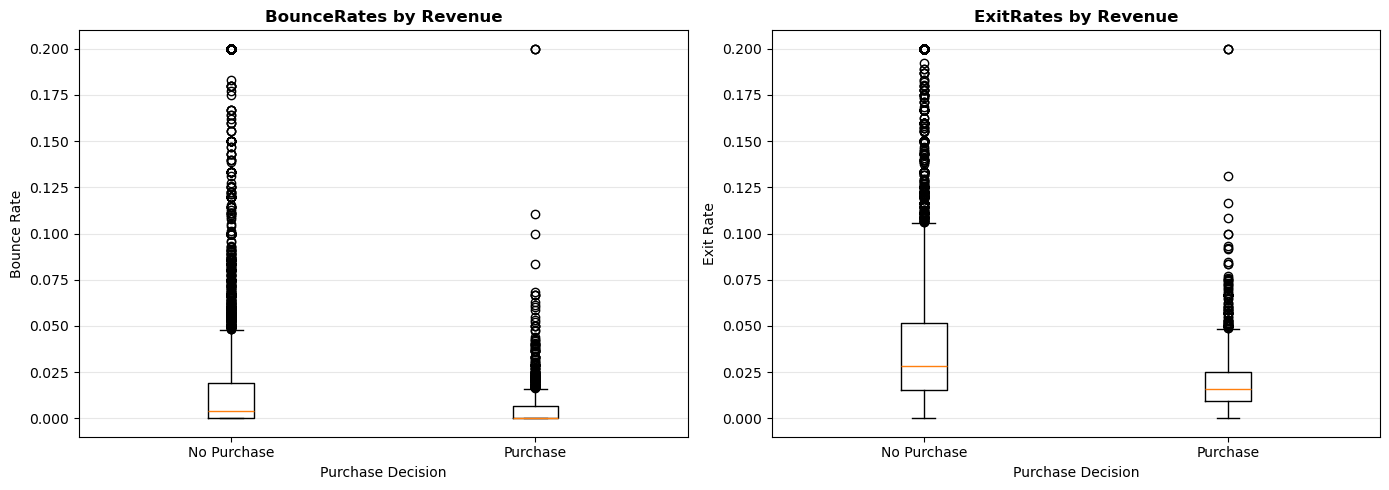

BounceRates by Revenue:

No Purchase - Mean: 0.0232, Median: 0.0039
Purchase - Mean: 0.0051, Median: 0.0000
Difference: 0.0181 (No Purchase is 353.3% higher)


ExitRates by Revenue:

No Purchase - Mean: 0.0455, Median: 0.0284
Purchase - Mean: 0.0196, Median: 0.0160
Difference: 0.0260 (No Purchase is 132.8% higher)


In [31]:
# compare engagement metrics between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BounceRates
br_purchase = df_clean[df_clean['Revenue'] == True]['BounceRates']
br_no_purchase = df_clean[df_clean['Revenue'] == False]['BounceRates']

axes[0].boxplot([br_no_purchase, br_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('BounceRates by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Bounce Rate', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ExitRates
er_purchase = df_clean[df_clean['Revenue'] == True]['ExitRates']
er_no_purchase = df_clean[df_clean['Revenue'] == False]['ExitRates']

axes[1].boxplot([er_no_purchase, er_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ExitRates by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("BounceRates by Revenue:\n")
print(f"No Purchase - Mean: {br_no_purchase.mean():.4f}, Median: {br_no_purchase.median():.4f}")
print(f"Purchase - Mean: {br_purchase.mean():.4f}, Median: {br_purchase.median():.4f}")
print(f"Difference: {br_no_purchase.mean() - br_purchase.mean():.4f} (No Purchase is {((br_no_purchase.mean() / br_purchase.mean() - 1) * 100):.1f}% higher)")

print("\n" + "="*60 + "\n")

print("ExitRates by Revenue:\n")
print(f"No Purchase - Mean: {er_no_purchase.mean():.4f}, Median: {er_no_purchase.median():.4f}")
print(f"Purchase - Mean: {er_purchase.mean():.4f}, Median: {er_purchase.median():.4f}")
print(f"Difference: {er_no_purchase.mean() - er_purchase.mean():.4f} (No Purchase is {((er_no_purchase.mean() / er_purchase.mean() - 1) * 100):.1f}% higher)")

**KEY FINDING:** The engagement metrics strongly differentiate purchasers from non-purchasers. Purchasers have dramatically lower BounceRates (0.0051 vs 0.0232, which is 353.3% lower) with a median of 0, meaning most purchasers engage with multiple pages rather than bouncing. Similarly, ExitRates are 132.8% lower for purchasers (0.0196 vs 0.0455). These metrics confirm that sustained engagement is a strong indicator of purchase intent. Users who bounce or exit quickly are much less likely to complete a purchase, making these valuable features for our classification model.

**2.2.4 Revenue vs Temporal Patterns**

We now examine whether purchase rates vary by time of visit. From our univariate analysis, we found strong seasonality in traffic (May and November peaks) and more weekday than weekend sessions. We want to see if conversion rates also differ across these temporal dimensions.

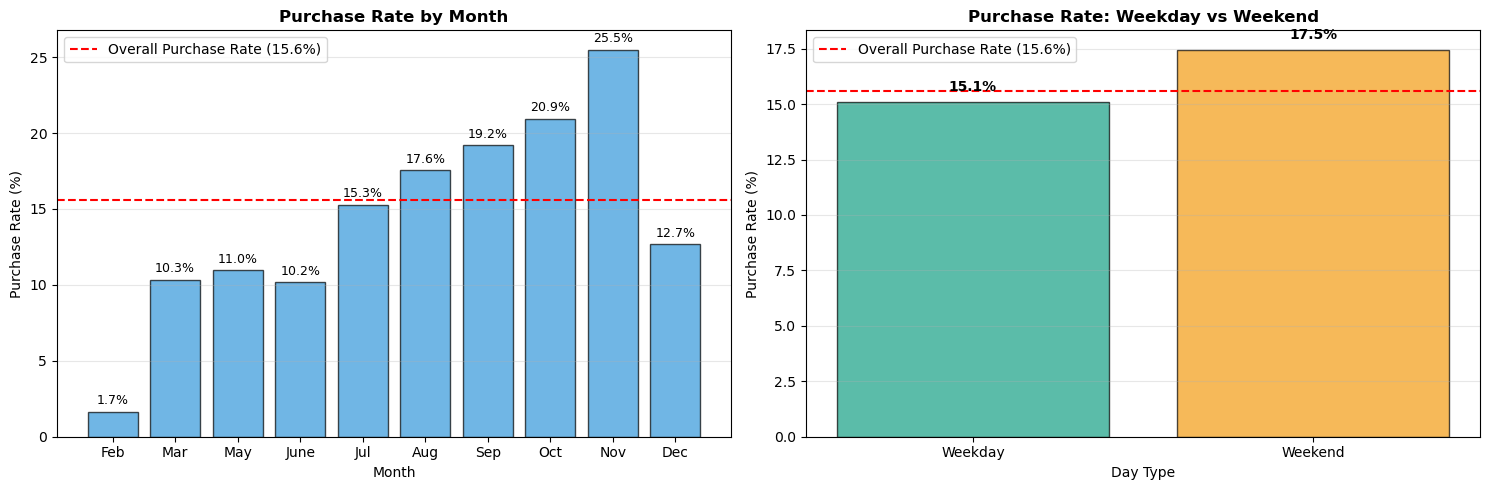

Purchase Rate by Month:

Feb   :  1.66% (   3 purchases /  181 sessions)
Mar   : 10.32% ( 192 purchases / 1860 sessions)
May   : 10.96% ( 365 purchases / 3329 sessions)
June  : 10.18% (  29 purchases /  285 sessions)
Jul   : 15.28% (  66 purchases /  432 sessions)
Aug   : 17.55% (  76 purchases /  433 sessions)
Sep   : 19.20% (  86 purchases /  448 sessions)
Oct   : 20.95% ( 115 purchases /  549 sessions)
Nov   : 25.49% ( 760 purchases / 2982 sessions)
Dec   : 12.66% ( 216 purchases / 1706 sessions)


Purchase Rate by Weekend:

Weekday: 15.08% (1409 purchases / 9346 sessions)
Weekend: 17.45% (499 purchases / 2859 sessions)


In [32]:
# calculate purchase rates by Month and Weekend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# purchase rate by Month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue = df_clean.groupby('Month')['Revenue'].agg(['sum', 'count'])
month_revenue['purchase_rate'] = (month_revenue['sum'] / month_revenue['count']) * 100
month_revenue = month_revenue.reindex(month_order)

axes[0].bar(month_revenue.index, month_revenue['purchase_rate'], color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Purchase Rate by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[0].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(month_revenue['purchase_rate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# purchase rate by Weekend
weekend_revenue = df_clean.groupby('Weekend')['Revenue'].agg(['sum', 'count'])
weekend_revenue['purchase_rate'] = (weekend_revenue['sum'] / weekend_revenue['count']) * 100

axes[1].bar(['Weekday', 'Weekend'], weekend_revenue['purchase_rate'].values, 
            color=['#16a085', '#f39c12'], edgecolor='black', alpha=0.7)
axes[1].set_title('Purchase Rate: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day Type', fontsize=10)
axes[1].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[1].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(weekend_revenue['purchase_rate'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Month:\n")
for month in month_order:
    rate = month_revenue.loc[month, 'purchase_rate']
    count = month_revenue.loc[month, 'count']
    purchases = month_revenue.loc[month, 'sum']
    print(f"{month:6s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):4d} sessions)")

print("\n" + "="*60 + "\n")

print("Purchase Rate by Weekend:\n")
print(f"Weekday: {weekend_revenue.loc[False, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[False, 'sum'])} purchases / {int(weekend_revenue.loc[False, 'count'])} sessions)")
print(f"Weekend: {weekend_revenue.loc[True, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[True, 'sum'])} purchases / {int(weekend_revenue.loc[True, 'count'])} sessions)")

**KEY FINDING:** Temporal patterns reveal significant variation in purchase behavior. Purchase rates vary dramatically by month, ranging from just 1.7% in February to 25.5% in November. There's a clear upward trend from summer through fall, with July-November all exceeding the overall 15.6% rate. November shows exceptional conversion (25.5%), likely due to holiday shopping and promotional events. This suggests seasonality is an important predictor. 

Interestingly, weekend sessions have a slightly higher conversion rate (17.5% vs 15.1%), indicating weekend shoppers may be more purchase-ready than weekday browsers. These temporal features should be included in our classification model as they capture behavioral differences across time periods.

**2.2.5 Revenue vs Visitor Characteristics**

Finally, we examine how visitor type influences purchase behavior. Our univariate analysis showed 85.5% returning visitors and 13.9% new visitors. We want to determine if returning visitors, who are familiar with the site, have higher conversion rates.

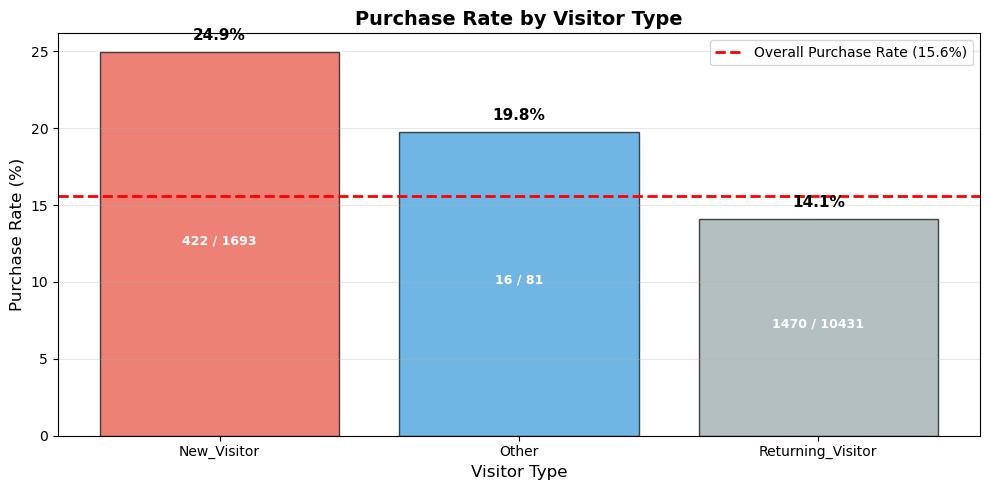

Purchase Rate by Visitor Type:

New_Visitor         : 24.93% ( 422 purchases /  1693 sessions)
Other               : 19.75% (  16 purchases /    81 sessions)
Returning_Visitor   : 14.09% (1470 purchases / 10431 sessions)


Returning visitors convert -10.83 percentage points lower than new visitors
Ratio: 0.57x


In [33]:
# calculate purchase rate by VisitorType
visitor_revenue = df_clean.groupby('VisitorType')['Revenue'].agg(['sum', 'count'])
visitor_revenue['purchase_rate'] = (visitor_revenue['sum'] / visitor_revenue['count']) * 100
visitor_revenue = visitor_revenue.sort_values('purchase_rate', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(visitor_revenue.index, visitor_revenue['purchase_rate'], 
               color=['#e74c3c', '#3498db', '#95a5a6'], edgecolor='black', alpha=0.7)
plt.title('Purchase Rate by Visitor Type', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Purchase Rate (%)', fontsize=12)
plt.axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)', linewidth=2)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# add value labels
for i, (idx, row) in enumerate(visitor_revenue.iterrows()):
    plt.text(i, row['purchase_rate'] + 0.8, f"{row['purchase_rate']:.1f}%", 
             ha='center', fontsize=11, fontweight='bold')
    plt.text(i, row['purchase_rate']/2, f"{int(row['sum'])} / {int(row['count'])}", 
             ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Visitor Type:\n")
for visitor_type in visitor_revenue.index:
    rate = visitor_revenue.loc[visitor_type, 'purchase_rate']
    count = visitor_revenue.loc[visitor_type, 'count']
    purchases = visitor_revenue.loc[visitor_type, 'sum']
    print(f"{visitor_type:20s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):5d} sessions)")

print("\n" + "="*70 + "\n")

# compare returning vs new (excluding "Other" due to small sample)
returning_rate = visitor_revenue.loc['Returning_Visitor', 'purchase_rate']
new_rate = visitor_revenue.loc['New_Visitor', 'purchase_rate']
print(f"Returning visitors convert {returning_rate - new_rate:.2f} percentage points {'higher' if returning_rate > new_rate else 'lower'} than new visitors")
print(f"Ratio: {returning_rate / new_rate:.2f}x")

**KEY FINDING:** Contrary to typical e-commerce assumptions, new visitors have a significantly HIGHER purchase rate (24.93%) than returning visitors (14.09%) - a 1.77x difference. This counter-intuitive result suggests several possibilities:

1. **Targeted acquisition**: New visitors may arrive through targeted marketing campaigns with specific purchase intent
2. **Research behavior**: Returning visitors might be comparison shopping or researching across multiple sessions before deciding
3. **Selection bias**: The dataset design (one session per user over 1 year) may capture new visitors at their moment of purchase, while returning visitors include many browse-only sessions
4. **Discount hunting**: Returning visitors might be waiting for promotions

The "Other" category shows 19.75% conversion but with only 81 sessions, making it less reliable. This finding highlights that VisitorType should be included in modeling, though its predictive direction differs from expectations. This also suggests we should examine the interaction between VisitorType and other features like PageValues.

**Summary of Bivariate Analysis:**

From our bivariate analysis, we have identified key predictors of purchase behavior:

**Strong Predictors (Large Effect):**
- **PageValues**: 13.6x higher mean for purchasers; 80.6% of purchases have non-zero PageValues
- **BounceRates**: 353% lower for purchasers; strong engagement indicator
- **ExitRates**: 133% lower for purchasers; confirms engagement importance

**Moderate Predictors (Medium Effect):**
- **ProductRelated features**: 66-73% higher for purchasers; more browsing = higher purchase likelihood
- **Month**: 1.7% to 25.5% range; November peak suggests strong seasonality effect
- **VisitorType**: Unexpected pattern with new visitors converting 1.77x better

**Weak Predictors (Small Effect):**
- **Weekend**: Small difference (17.5% vs 15.1%); weekend shoppers slightly more likely to purchase

These insights will directly inform our feature engineering and model building in the next phase.

### 2.3 Correlation Analysis

Correlation analysis helps us understand relationships between numerical features and identify potential multicollinearity issues. This is crucial for feature selection and model building.

**2.3.1 Correlation Heatmap**

We examine correlations between all numerical features to identify redundant features (high correlation indicates similar information) and understand feature relationships.

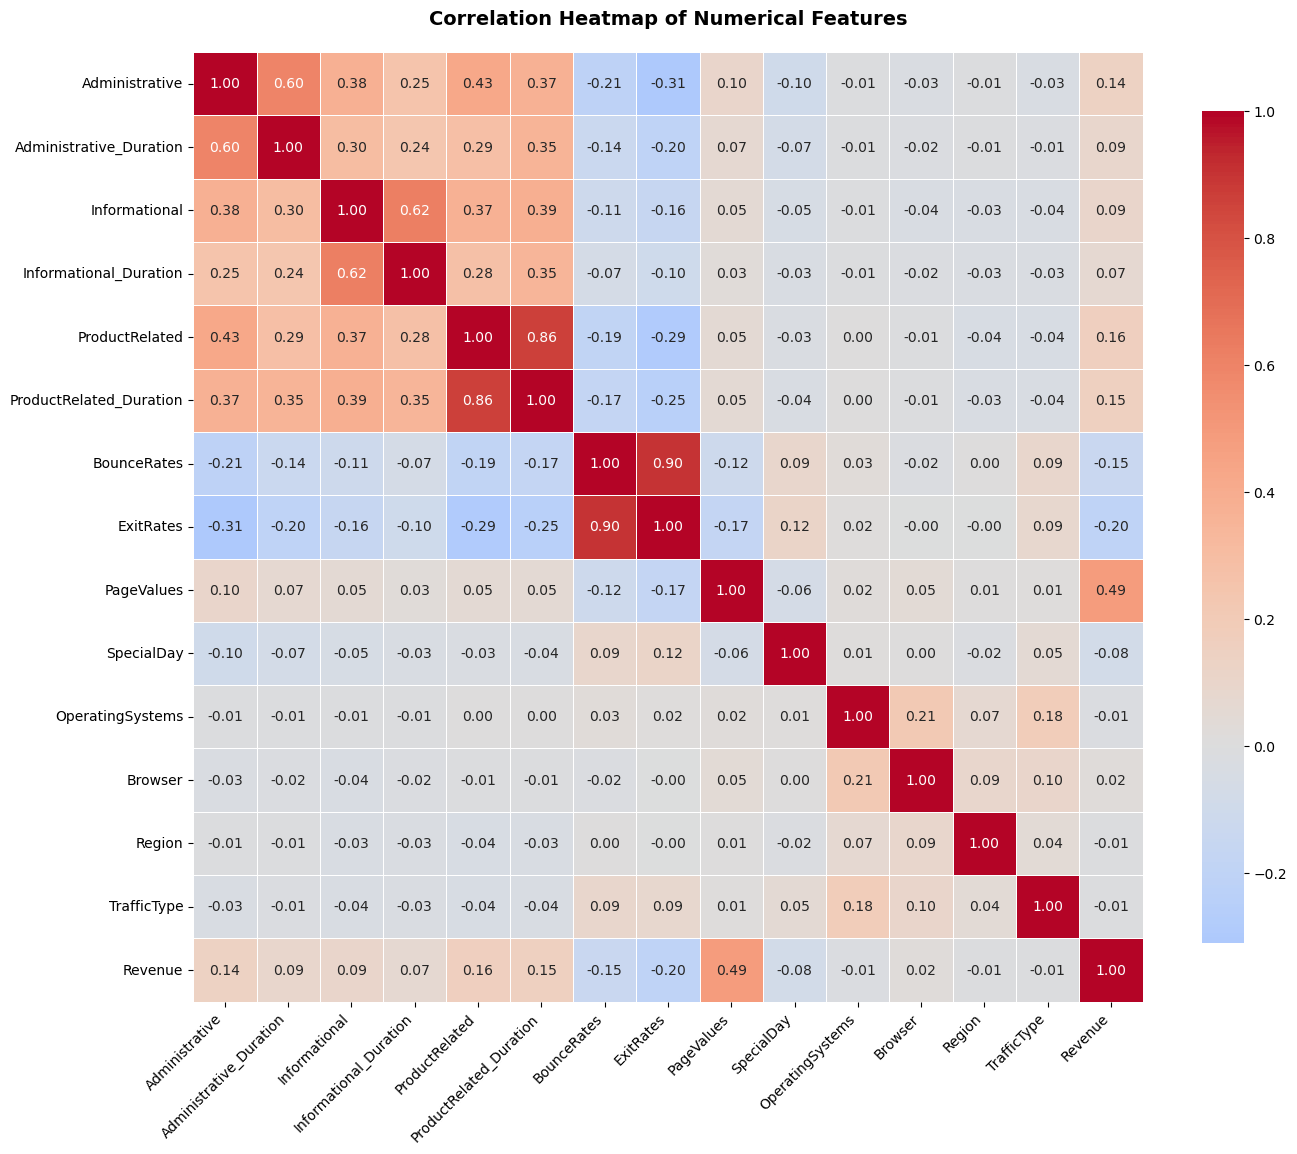

Highly Correlated Feature Pairs (|correlation| > 0.7):

ProductRelated                 <-> ProductRelated_Duration        :  0.860
BounceRates                    <-> ExitRates                      :  0.902


In [34]:
# create correlation matrix for all numerical features
numerical_features = ['Administrative', 'Administrative_Duration', 'Informational', 
                     'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                     'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                     'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# convert Revenue to numeric for correlation
df_corr = df_clean.copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)

# calculate correlation matrix
correlation_matrix = df_corr[numerical_features + ['Revenue']].corr()

# create heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# identify highly correlated pairs (threshold > 0.7)
print("Highly Correlated Feature Pairs (|correlation| > 0.7):\n")
print("="*70)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((feature1, feature2, corr_value))
            print(f"{feature1:30s} <-> {feature2:30s} : {corr_value:6.3f}")

if len(high_corr_pairs) == 0:
    print("No feature pairs with correlation > 0.7 found.")

**Key Correlation Insights:**

The heatmap reveals two important highly correlated pairs that indicate multicollinearity:

1. **ProductRelated & ProductRelated_Duration (0.86)**: Strong positive correlation indicates that users who visit more product pages naturally spend more time browsing. While both are predictive of purchases, they contain overlapping information.

2. **BounceRates & ExitRates (0.90)**: Very high correlation shows these metrics measure similar exit behavior. This is the strongest multicollinearity in our dataset and suggests we should consider keeping only one of these features in our final model.

**Positive Findings:**
- Most features show low to moderate correlations (< 0.7), indicating they provide unique information
- System features (OperatingSystems, Browser, Region, TrafficType) have very low correlations with other features, suggesting they capture independent user characteristics
- PageValues shows relatively low correlation with most features except Revenue, confirming it provides unique predictive value

**Implications for Modeling:**
To avoid multicollinearity issues, we may need to drop one feature from each highly correlated pair during feature selection. This will be addressed in the feature engineering phase.

**2.3.2 Feature Correlation with Target (Revenue)**

Now we examine which features have the strongest correlation with our target variable. This helps us rank features by their potential predictive power for classification.

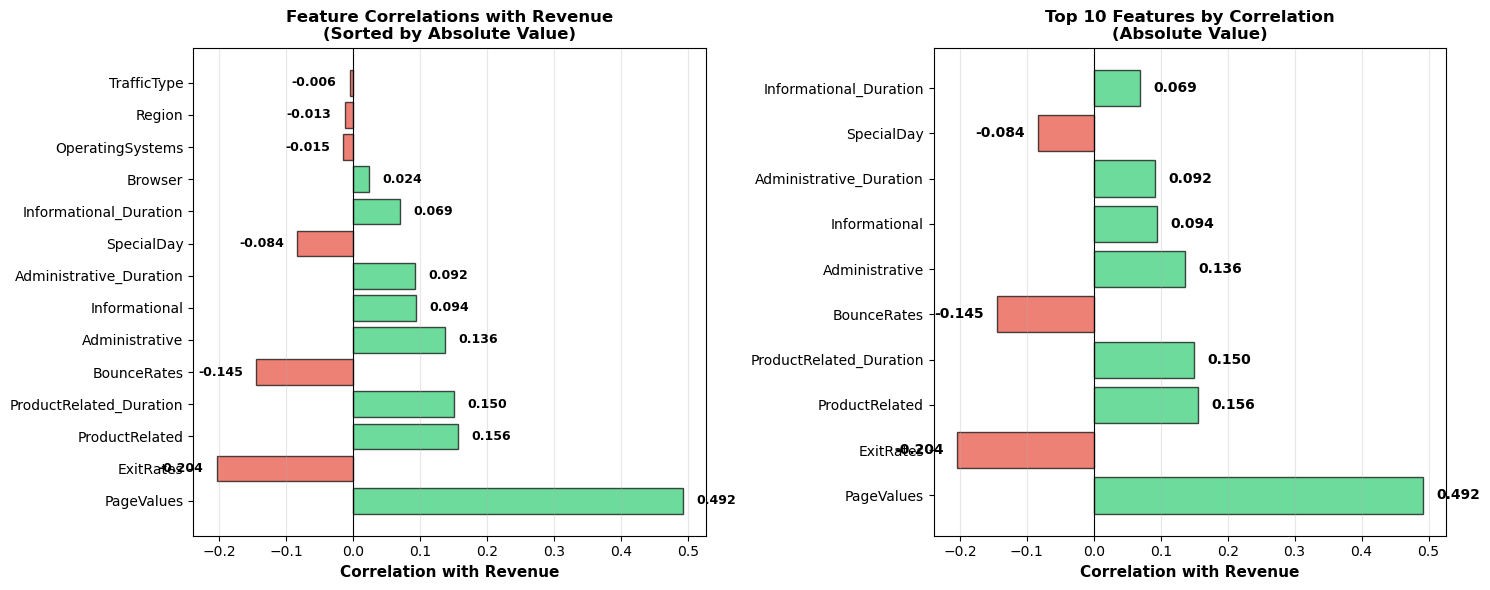

Feature Correlation with Revenue (Ranked by Absolute Value):

Rank   Feature                         Correlation Direction      
1      PageValues                           0.4919   Positive       
2      ExitRates                           -0.2043   Negative       
3      ProductRelated                       0.1560   Positive       
4      ProductRelated_Duration              0.1501   Positive       
5      BounceRates                         -0.1451   Negative       
6      Administrative                       0.1363   Positive       
7      Informational                        0.0936   Positive       
8      Administrative_Duration              0.0918   Positive       
9      SpecialDay                          -0.0836   Negative       
10     Informational_Duration               0.0694   Positive       
11     Browser                              0.0241   Positive       
12     OperatingSystems                    -0.0149   Negative       
13     Region                              

In [35]:
# extract correlations with Revenue and sort by absolute value
revenue_correlations = correlation_matrix['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)

# create bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# plot 1: All correlations sorted by absolute value
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in revenue_correlations.values]
axes[0].barh(range(len(revenue_correlations)), revenue_correlations.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(revenue_correlations)))
axes[0].set_yticklabels(revenue_correlations.index)
axes[0].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Correlations with Revenue\n(Sorted by Absolute Value)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(revenue_correlations.values):
    axes[0].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=9, fontweight='bold')

# plot 2: Top 10 features only
top_10 = revenue_correlations.head(10)
colors_top10 = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_10.values]
axes[1].barh(range(len(top_10)), top_10.values, color=colors_top10, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_10)))
axes[1].set_yticklabels(top_10.index)
axes[1].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Features by Correlation\n(Absolute Value)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(top_10.values):
    axes[1].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed ranking
print("Feature Correlation with Revenue (Ranked by Absolute Value):\n")
print("="*70)
print(f"{'Rank':<6} {'Feature':<30} {'Correlation':>12} {'Direction':<15}")
print("="*70)

for rank, (feature, corr) in enumerate(revenue_correlations.items(), 1):
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{rank:<6} {feature:<30} {corr:>12.4f}   {direction:<15}")

print("\n" + "="*70)
print("\nInterpretation:")
print("- Positive correlation: Higher feature value → Higher purchase likelihood")
print("- Negative correlation: Higher feature value → Lower purchase likelihood")

**Feature Importance Ranking Analysis:**

The correlation analysis confirms our bivariate findings and provides clear feature importance ranking:

**Tier 1 - Strong Predictors (|correlation| > 0.15):**
- **PageValues (0.49)**: By far the strongest predictor. This validates our bivariate analysis where 80.6% of purchases had non-zero PageValues. This feature should be prioritized in all models.
- **ExitRates (-0.20)**: Negative correlation confirms that lower exit rates indicate higher purchase likelihood
- **ProductRelated features (0.15-0.16)**: Both page visits and duration show moderate positive correlation

**Tier 2 - Moderate Predictors (0.09 < |correlation| < 0.15):**
- **BounceRates (-0.15)**: Similar to ExitRates, lower bounce indicates better engagement
- **Administrative features (0.09-0.14)**: Weak but present positive relationship
- **Informational features (0.07-0.09)**: Very weak positive relationship

**Tier 3 - Weak/Negligible Predictors (|correlation| < 0.09):**
- **SpecialDay (-0.08)**: Slight negative correlation, contrary to expectations
- **System features** (Browser, OS, Region, TrafficType): All near-zero correlations (< 0.03), suggesting these don't directly predict purchases

**Critical Insights for Feature Engineering:**
1. Focus modeling efforts on Tier 1 features, especially PageValues
2. Resolve multicollinearity by selecting one feature from correlated pairs (ExitRates vs BounceRates, ProductRelated vs ProductRelated_Duration)
3. Consider dropping or transforming Tier 3 features with minimal predictive value
4. Categorical features (Month, VisitorType, Weekend) not shown here but proved important in bivariate analysis - these will be encoded and included

### 2.4 Feature Selection

Based on our correlation analysis, we identified multicollinearity issues and weak predictors. We will now systematically remove redundant and non-informative features.

In [36]:
# create working copy for feature engineering
df_fe = df_clean.copy()

print("Original dataset shape:", df_fe.shape)
print("\nFeature Selection Decisions Based on EDA:\n")
print("="*70)

# decision 1: remove BounceRates (keep ExitRates)
print("\n1. Multicollinearity Resolution: BounceRates vs ExitRates")
print("   - Correlation: 0.90 (very high redundancy)")
print("   - ExitRates correlation with Revenue: -0.20")
print("   - BounceRates correlation with Revenue: -0.15")
print("   Decision: DROP BounceRates, KEEP ExitRates")

# decision 2: keep both ProductRelated features
print("\n2. ProductRelated vs ProductRelated_Duration")
print("   - Correlation: 0.86 (high but not extreme)")
print("   - Both show 0.15-0.16 correlation with Revenue")
print("   - Duration may capture time-based patterns not in count")
print("   Decision: KEEP BOTH (they provide complementary information)")

# decision 3: remove weak system features
print("\n3. Weak Predictor Removal:")
print("   - TrafficType correlation: -0.006")
print("   - Region correlation: -0.013")
print("   - OperatingSystems correlation: -0.015")
print("   - Browser correlation: 0.024")
print("   Decision: DROP all 4 features (negligible predictive power)")

# decision 4: keep all strong and moderate features
print("\n4. Features to KEEP:")
print("   Strong: PageValues, ExitRates, ProductRelated, ProductRelated_Duration")
print("   Moderate: Administrative, Administrative_Duration, Informational, Informational_Duration")
print("   Weak but keep: SpecialDay (may interact with Month)")
print("   Categorical: Month, VisitorType, Weekend, Revenue (target)")

print("\n" + "="*70)

# apply feature selection
features_to_drop = ['BounceRates', 'TrafficType', 'Region', 'OperatingSystems', 'Browser']
df_fe = df_fe.drop(columns=features_to_drop)

print(f"\nFeatures dropped: {features_to_drop}")
print(f"New dataset shape: {df_fe.shape}")
print(f"Features removed: {len(features_to_drop)}")
print(f"Features remaining: {df_fe.shape[1]}")

Original dataset shape: (12205, 18)

Feature Selection Decisions Based on EDA:


1. Multicollinearity Resolution: BounceRates vs ExitRates
   - Correlation: 0.90 (very high redundancy)
   - ExitRates correlation with Revenue: -0.20
   - BounceRates correlation with Revenue: -0.15
   Decision: DROP BounceRates, KEEP ExitRates

2. ProductRelated vs ProductRelated_Duration
   - Correlation: 0.86 (high but not extreme)
   - Both show 0.15-0.16 correlation with Revenue
   - Duration may capture time-based patterns not in count
   Decision: KEEP BOTH (they provide complementary information)

3. Weak Predictor Removal:
   - TrafficType correlation: -0.006
   - Region correlation: -0.013
   - OperatingSystems correlation: -0.015
   - Browser correlation: 0.024
   Decision: DROP all 4 features (negligible predictive power)

4. Features to KEEP:
   Strong: PageValues, ExitRates, ProductRelated, ProductRelated_Duration
   Moderate: Administrative, Administrative_Duration, Informational, Informati

Our feature selection reduced the dataset from 18 to 13 features by removing 5 features: BounceRates (redundant with ExitRates), and 4 weak system features (TrafficType, Region, OperatingSystems, Browser). This eliminates multicollinearity and focuses on predictive features.

### 2.5 Categorical Encoding

Machine learning algorithms require numerical input. We will encode our categorical features (Month, VisitorType, Weekend) using appropriate methods.

One-Hot Encoding transformed Month (10 categories) and VisitorType (3 categories) into 13 binary columns. Combined with binary encoding for Weekend and Revenue, our dataset expanded from 13 to 24 features. Each month/visitor type now has its own column with 1 (present) or 0 (absent), allowing models to learn category-specific patterns without assuming ordinal relationships.

### 2.6 Train-Test Split and Feature Scaling

We will split the data into training and testing sets with stratification to maintain the class balance, then apply feature scaling to normalize numerical features.

In [38]:
# separate features and target
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True) * 100}")

Feature matrix shape: (12205, 23)
Target vector shape: (12205,)

Target distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64

Class balance: Revenue
0    84.367063
1    15.632937
Name: proportion, dtype: float64


In [39]:
# train-test split with stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split Results:\n")
print("="*70)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"Percentage: {y_train.value_counts(normalize=True) * 100}")
print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"Percentage: {y_test.value_counts(normalize=True) * 100}")

Train-Test Split Results:

Training set size: 9764 samples (80.0%)
Test set size: 2441 samples (20.0%)

Training set class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64
Percentage: Revenue
0    84.371159
1    15.628841
Name: proportion, dtype: float64

Test set class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64
Percentage: Revenue
0    84.350676
1    15.649324
Name: proportion, dtype: float64


In [40]:
# feature scaling for numerical features
from sklearn.preprocessing import StandardScaler

# identify numerical columns (excluding one-hot encoded)
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                 'ExitRates', 'PageValues', 'SpecialDay']

print("Applying StandardScaler to numerical features:\n")
print("="*70)
print(f"Numerical features to scale: {numerical_cols}")
print(f"\nScaling method: Standardization (mean=0, std=1)")
print("Note: Scaling applied separately to train and test to prevent data leakage")

# fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n" + "="*70)
print("Scaling Statistics (Training Set):\n")
for col in numerical_cols[:3]:  # show first 3 as example
    print(f"{col}:")
    print(f"  Before: mean={X_train[col].mean():.2f}, std={X_train[col].std():.2f}")
    print(f"  After:  mean={X_train_scaled[col].mean():.2f}, std={X_train_scaled[col].std():.2f}")

Applying StandardScaler to numerical features:

Numerical features to scale: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 'SpecialDay']

Scaling method: Standardization (mean=0, std=1)
Note: Scaling applied separately to train and test to prevent data leakage

Scaling Statistics (Training Set):

Administrative:
  Before: mean=2.34, std=3.35
  After:  mean=-0.00, std=1.00
Administrative_Duration:
  Before: mean=82.22, std=179.50
  After:  mean=-0.00, std=1.00
Informational:
  Before: mean=0.51, std=1.28
  After:  mean=-0.00, std=1.00


In [41]:
# check current categorical features
print("Categorical Features Before Encoding:\n")
print("="*70)
categorical_features = df_fe.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in categorical_features:
    unique_vals = df_fe[col].nunique()
    print(f"{col:20s}: {unique_vals} unique values - {df_fe[col].unique()[:5]}")

print("\n" + "="*70)
print("\nEncoding Strategy:\n")
print("1. Month (10 categories): One-Hot Encoding")
print("   Reason: Nominal variable, no inherent order")
print("\n2. VisitorType (3 categories): One-Hot Encoding")
print("   Reason: Nominal variable, no inherent order")
print("\n3. Weekend (Boolean): Binary encoding (0/1)")
print("   Reason: Already binary, simple conversion")
print("\n4. Revenue (Target): Binary encoding (0/1)")
print("   Reason: Target variable for classification")

# apply one-hot encoding to Month and VisitorType
df_encoded = pd.get_dummies(df_fe, columns=['Month', 'VisitorType'], prefix=['Month', 'VisitorType'], drop_first=False)

# convert boolean to integer
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

print("\n" + "="*70)
print(f"\nDataset shape after encoding: {df_encoded.shape}")
print(f"Features before encoding: {df_fe.shape[1]}")
print(f"Features after encoding: {df_encoded.shape[1]}")
print(f"New features created: {df_encoded.shape[1] - df_fe.shape[1]}")

# show new column names
print("\nNew encoded features:")
new_cols = [col for col in df_encoded.columns if col not in df_fe.columns or col in ['Weekend', 'Revenue']]
print(new_cols)

Categorical Features Before Encoding:

Month               : 10 unique values - ['Feb' 'Mar' 'May' 'Oct' 'June']
VisitorType         : 3 unique values - ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend             : 2 unique values - [False  True]
Revenue             : 2 unique values - [False  True]


Encoding Strategy:

1. Month (10 categories): One-Hot Encoding
   Reason: Nominal variable, no inherent order

2. VisitorType (3 categories): One-Hot Encoding
   Reason: Nominal variable, no inherent order

3. Weekend (Boolean): Binary encoding (0/1)
   Reason: Already binary, simple conversion

4. Revenue (Target): Binary encoding (0/1)
   Reason: Target variable for classification


Dataset shape after encoding: (12205, 24)
Features before encoding: 13
Features after encoding: 24
New features created: 11

New encoded features:
['Weekend', 'Revenue', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'Vis